# World Energy Consumption - Country Selection EDA

**Purpose:** Determine which countries to use for Model 1 (MLP, cross-sectional) and Model 3 (ARIMA, time series), and validate the final feature set for Model 1.

**Key findings:**
- Model 1 uses **2018**, the last year with complete GDP and energy_per_gdp data
- Model 1 has **69 countries** with fully complete feature data
- Final features chosen from EDA: `gas_share_elec`, `per_capita_electricity`, `fossil_elec_per_capita`, `gas_elec_per_capita`, `coal_share_energy`, `energy_per_gdp`, `energy_per_capita`
- Model 3: drop Saudi Arabia (only 10 data points, all 0%). Final 5 countries: **Germany, USA, China, India, Brazil**

---
## Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

TARGET    = 'renewables_share_energy'
DATA_PATH = '../data/World_Energy_Consumption.csv'  

# Final feature set which was chosen based on correlation analysis in EDA_World_Energy_Consumption.ipynb
# These replace the original spec features (gdp, oil_share_energy, greenhouse_gas_emissions,
# population) which had near-zero correlation with the target.
FEATURES = [
    'gas_share_elec', # gas share of electricity generation (r = -0.50)
    'per_capita_electricity', # electricity use per person (r = +0.47)
    'fossil_elec_per_capita', # fossil electricity per person (r = -0.42)
    'gas_elec_per_capita', # gas electricity per person (r = -0.37)
    'coal_share_energy', # coal share of total energy (r = -0.28)
    'energy_per_gdp', # energy intensity of economy (r = -0.19)
    'energy_per_capita', # total energy use per person (r = +0.15)
]

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Year range: {df["year"].min()} to {df["year"].max()}')

Loaded: 22,012 rows x 129 columns
Year range: 1900 to 2022


---
## 1. Why 2018 and not more recent years?

`energy_per_gdp` (energy intensity) is absent from 2019 onward in this dataset. Since energy intensity is one of our features, 2018 is the most recent viable year.

In [14]:
print('Feature availability by year (sovereign countries only)')
print(f'{"Year":<8} {"energy_per_gdp":<18} {"gas_share_elec":<18} {"renewables_share":<20} {"n countries"}')
print('-' * 72)

for yr in range(2015, 2023):
    sub = df[
        (df['year'] == yr) &
        df['iso_code'].notna() &
        (df['iso_code'].str.len() == 3)
    ]
    epg_n = sub['energy_per_gdp'].notna().sum()
    gse_n = sub['gas_share_elec'].notna().sum()
    rse_n = sub[TARGET].notna().sum()
    n_full = sub[FEATURES + [TARGET]].dropna().shape[0]
    print(f'{yr:<8} {epg_n:<18} {gse_n:<18} {rse_n:<20} {n_full}')

print()
print('energy_per_gdp drops to 0 from 2019 onward, use 2018.')

Feature availability by year (sovereign countries only)
Year     energy_per_gdp     gas_share_elec     renewables_share     n countries
------------------------------------------------------------------------
2015     165                205                68                   68
2016     165                205                68                   68
2017     165                205                69                   69
2018     165                205                69                   69
2019     0                  205                69                   0
2020     0                  205                68                   0
2021     0                  205                68                   0
2022     0                  80                 68                   0

energy_per_gdp drops to 0 from 2019 onward, use 2018.


---
## 2. Model 1 (MLP) - 2018 Cross-Section: Complete Country List

In [15]:
# Filter to 2018 sovereign countries
df_2018 = df[
    (df['year'] == 2018) &
    df['iso_code'].notna() &
    (df['iso_code'].str.len() == 3)
].copy()

# Countries with all features present
complete_2018 = df_2018.dropna(subset=FEATURES + [TARGET]).copy()

print(f'Total sovereign countries in 2018: {len(df_2018)}')
print(f'Countries with complete feature data: {len(complete_2018)}')
print(f'Dropped (any feature missing): {len(df_2018) - len(complete_2018)}')
print()
print('Missing rate per feature (all 2018 sovereign countries):')
for f in FEATURES + [TARGET]:
    pct = df_2018[f].isna().mean() * 100
    print(f'  {f:<35} {pct:.1f}% missing')

Total sovereign countries in 2018: 219
Countries with complete feature data: 69
Dropped (any feature missing): 150

Missing rate per feature (all 2018 sovereign countries):
  gas_share_elec                      6.4% missing
  per_capita_electricity              2.3% missing
  fossil_elec_per_capita              2.3% missing
  gas_elec_per_capita                 5.5% missing
  coal_share_energy                   68.5% missing
  energy_per_gdp                      24.7% missing
  energy_per_capita                   1.4% missing
  renewables_share_energy             68.5% missing


In [16]:
# Full list of 69 countries sorted by renewables share
display_cols = ['country', TARGET, 'gas_share_elec', 'per_capita_electricity',
                'coal_share_energy', 'fossil_elec_per_capita']
model1_table = (
    complete_2018[display_cols]
    .sort_values(TARGET, ascending=False)
    .reset_index(drop=True)
)
model1_table.index += 1

print('MODEL 1: All 69 Countries (2018, complete data)')
print(model1_table.to_string())

MODEL 1: All 69 Countries (2018, complete data)
                country  renewables_share_energy  gas_share_elec  per_capita_electricity  coal_share_energy  fossil_elec_per_capita
1                Norway                    69.60            1.49                27487.04               1.69                  557.20
2                Brazil                    45.43            8.81                 2826.99               5.49                  412.48
3                Sweden                    42.24            0.23                16075.10               3.69                  360.15
4           New Zealand                    38.04           12.06                 8975.87               6.06                 1473.59
5               Austria                    34.53           15.25                 7357.03               7.91                 1694.47
6           Switzerland                    32.54            0.00                 7313.47               0.37                  415.76
7               Denmark     

---
## 3. Model 1 (MLP) - Country Distribution Check

Good coverage across renewables levels ensures the MLP sees the full range of the target. We check for imbalances that might bias the model toward the dense 0-20% region.

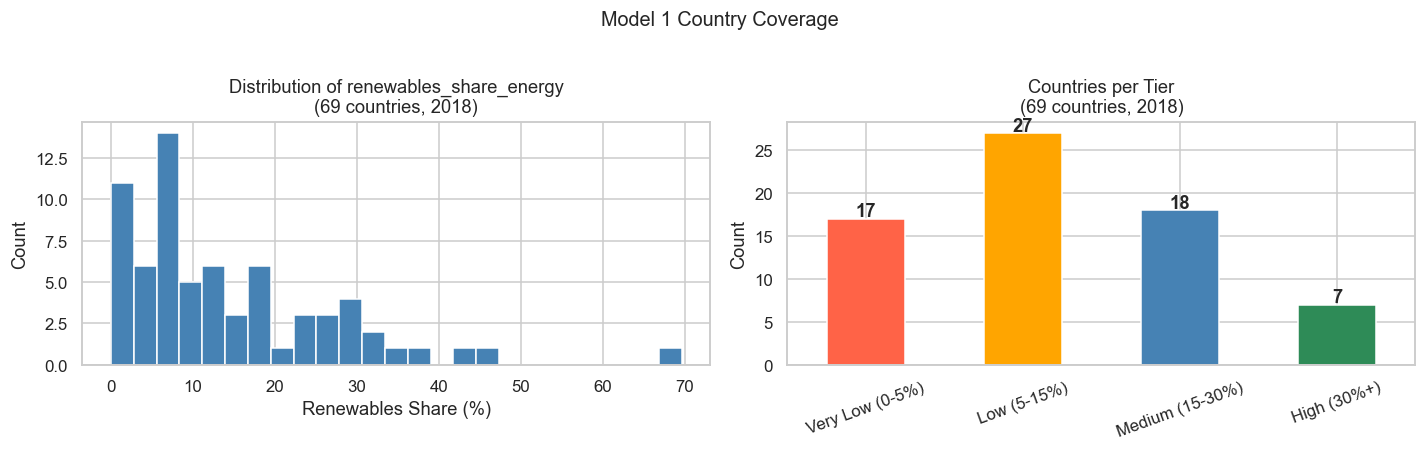

tier
Very Low (0-5%)    17
Low (5-15%)        27
Medium (15-30%)    18
High (30%+)         7
Name: count, dtype: int64

Mean : 14.4%  |  Std : 13.1%
Min : 0.01%  |  Max : 69.6%


In [ ]:
# Categorize countries into tiers based on their renewables share percentage
complete_2018['tier'] = pd.cut(
    complete_2018[TARGET],
    bins=[0, 5, 15, 30, 100],
    labels=['Very Low (0-5%)', 'Low (5-15%)', 'Medium (15-30%)', 'High (30%+)']
)

# Count the number of countries in each tier and sort the results by tier order
tier_counts = complete_2018['tier'].value_counts().sort_index()

# Create a figure with two subplots to visualize the data
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot a histogram of renewables share percentages
axes[0].hist(complete_2018[TARGET], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of renewables_share_energy\n(69 countries, 2018)')
axes[0].set_xlabel('Renewables Share (%)')
axes[0].set_ylabel('Count')

# Plot a bar chart of the number of countries in each tier
colors = ['tomato', 'orange', 'steelblue', 'seagreen']
tier_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', rot=20)
axes[1].set_title('Countries per Tier\n(69 countries, 2018)')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')

# Annotate the bar chart with the count values for each tier
for i, v in enumerate(tier_counts):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Add a title for the entire figure and adjust layout for better spacing
plt.suptitle('Model 1 Country Coverage', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print the tier counts and summary statistics for the renewables share
print(tier_counts)
print(f'\nMean : {complete_2018[TARGET].mean():.1f}%  |  Std : {complete_2018[TARGET].std():.1f}%')
print(f'Min : {complete_2018[TARGET].min():.2f}%  |  Max : {complete_2018[TARGET].max():.1f}%')

---
## 4. Feature Distributions in the 2018 Cross-Section

Checking whether the chosen features show enough variation across countries to be useful. A feature with near-zero variance would not help the model discriminate between countries.

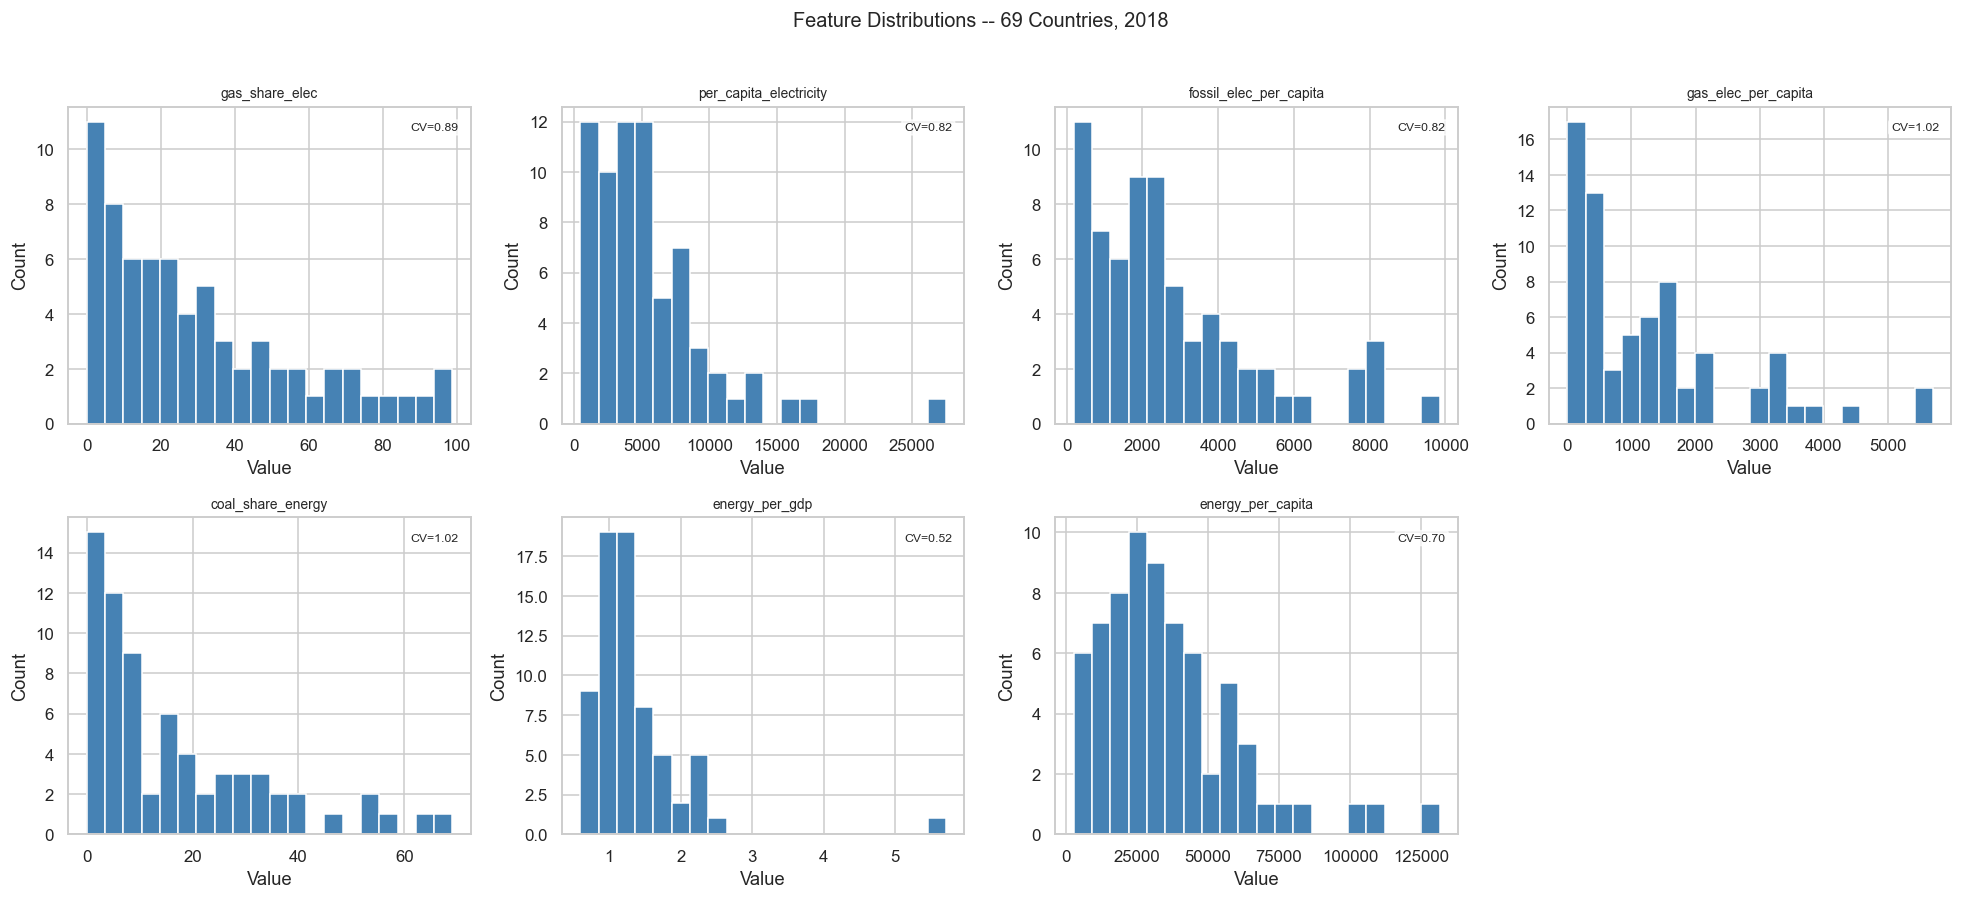

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(complete_2018[feat].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    cv = complete_2018[feat].std() / complete_2018[feat].mean()
    axes[i].text(0.97, 0.95, f'CV={cv:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

axes[-1].axis('off')
plt.suptitle('Feature Distributions -- 69 Countries, 2018', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Expected MLP Outliers - Pre-labelling

Before running the model, we can identify countries likely to produce large residuals by comparing their actual renewables rank against what their structural features would predict. This gives us a hypothesis to test against the MLP's actual residuals.

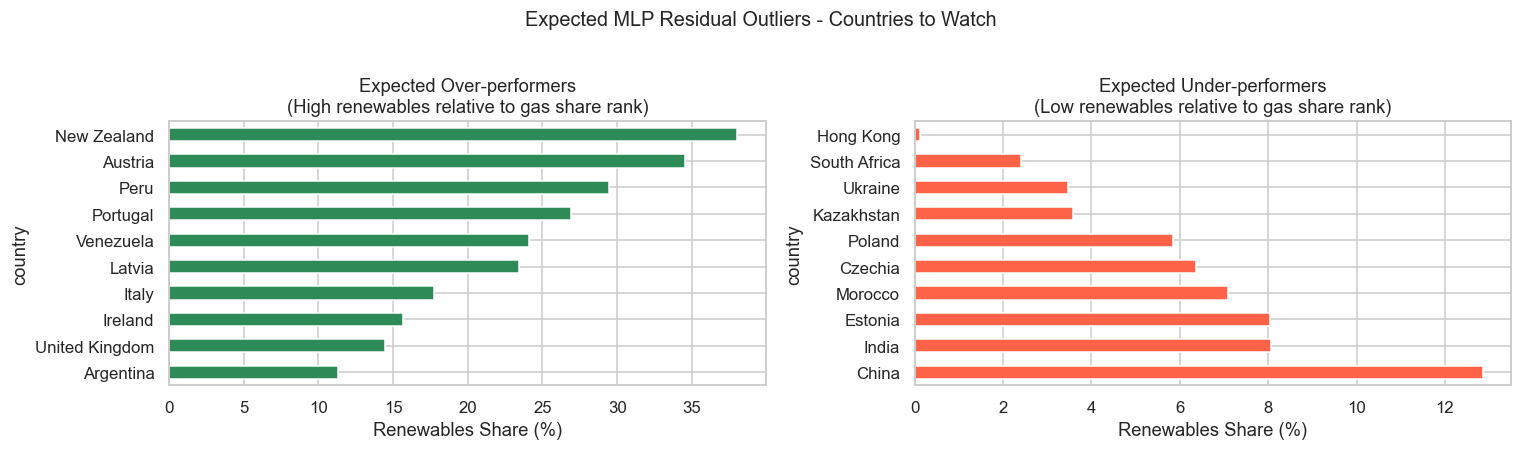

EXPECTED OVER-PERFORMERS (likely positive residuals from MLP):
       country  renewables_share_energy  gas_share_elec
        Latvia                    23.44           47.92
          Peru                    29.43           30.83
       Ireland                    15.68           51.84
         Italy                    17.73           44.73
     Argentina                    11.33           64.21
      Portugal                    26.88           26.73
United Kingdom                    14.49           39.78
     Venezuela                    24.07           26.37
       Austria                    34.53           15.25
   New Zealand                    38.04           12.06

EXPECTED UNDER-PERFORMERS (likely negative residuals from MLP):
     country  renewables_share_energy  gas_share_elec
South Africa                     2.41            0.00
     Ukraine                     3.46            6.69
     Czechia                     6.36            4.34
     Estonia                     8.03   

In [19]:
# Use gas_share_elec as the primary structural predictor for this pre-analysis
# (highest correlation with target at r = -0.50)
# Low gas share + high renewables = over-performer; high gas share + low renewables = under-performer
complete_2018['gas_rank'] = complete_2018['gas_share_elec'].rank(ascending=False)  # higher rank = more gas
complete_2018['renewables_rank'] = complete_2018[TARGET].rank(ascending=True)
complete_2018['rank_gap'] = complete_2018['renewables_rank'] - complete_2018['gas_rank']

over  = complete_2018.nlargest(10, 'rank_gap')[['country', TARGET, 'gas_share_elec', 'rank_gap']]
under = complete_2018.nsmallest(10, 'rank_gap')[['country', TARGET, 'gas_share_elec', 'rank_gap']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

over.set_index('country')[TARGET].sort_values().plot(
    kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Expected Over-performers\n(High renewables relative to gas share rank)')
axes[0].set_xlabel('Renewables Share (%)')

under.set_index('country')[TARGET].sort_values(ascending=False).plot(
    kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Expected Under-performers\n(Low renewables relative to gas share rank)')
axes[1].set_xlabel('Renewables Share (%)')

plt.suptitle('Expected MLP Residual Outliers - Countries to Watch', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('EXPECTED OVER-PERFORMERS (likely positive residuals from MLP):')
print(over[['country', TARGET, 'gas_share_elec']].to_string(index=False))
print()
print('EXPECTED UNDER-PERFORMERS (likely negative residuals from MLP):')
print(under[['country', TARGET, 'gas_share_elec']].to_string(index=False))

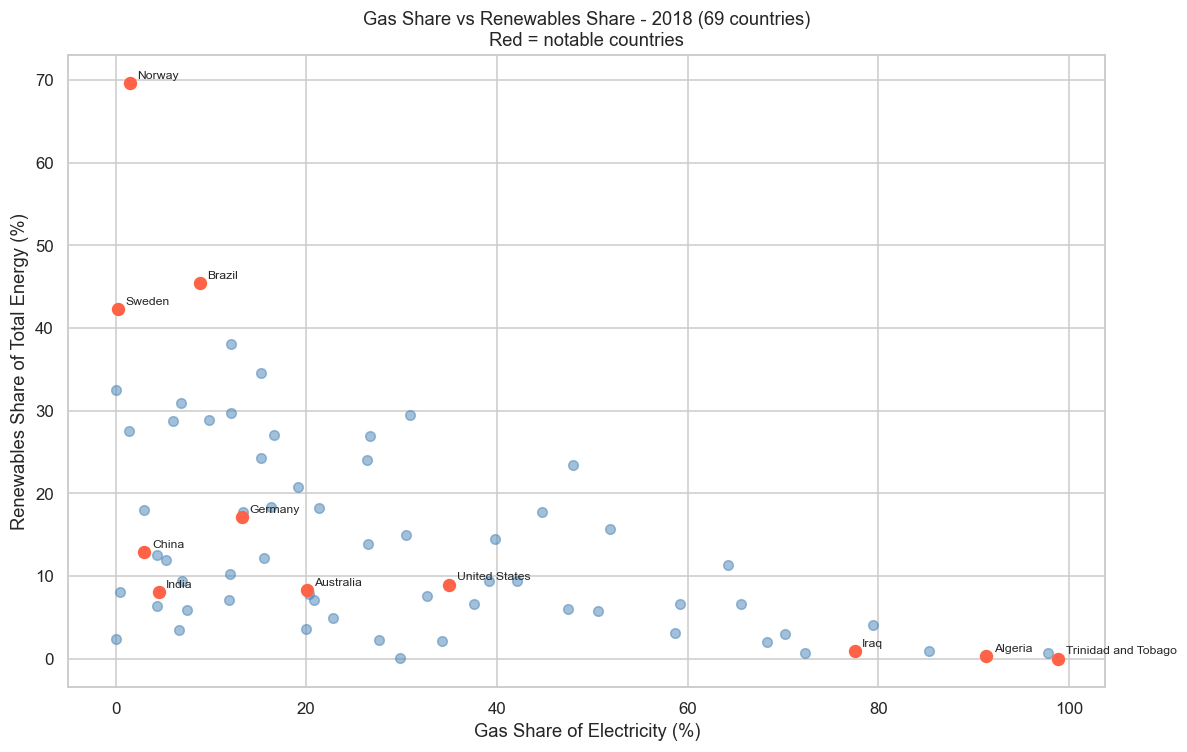

In [20]:
# gas_share_elec vs renewables share scatterplot
highlight = ['Norway', 'Brazil', 'Sweden', 'United States', 'Australia',
             'China', 'India', 'Germany', 'Trinidad and Tobago', 'Iraq', 'Algeria']

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(complete_2018['gas_share_elec'], complete_2018[TARGET],
           alpha=0.5, s=40, color='steelblue', label='All countries')

for _, row in complete_2018[complete_2018['country'].isin(highlight)].iterrows():
    ax.scatter(row['gas_share_elec'], row[TARGET], color='tomato', s=60, zorder=5)
    ax.annotate(row['country'], (row['gas_share_elec'], row[TARGET]),
                textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.set_xlabel('Gas Share of Electricity (%)')
ax.set_ylabel('Renewables Share of Total Energy (%)')
ax.set_title('Gas Share vs Renewables Share - 2018 (69 countries)\nRed = notable countries')
plt.tight_layout()
plt.show()

---
## 6. Model 3 (ARIMA) - Country Selection

ARIMA requires a genuine time series for each country. We evaluate candidate countries on data availability and trajectory diversity.

In [21]:
candidates = [
    'Germany', 'United States', 'China', 'India', 'Saudi Arabia',
    'Brazil', 'Norway', 'Australia', 'Japan', 'United Kingdom',
    'France', 'South Africa', 'Indonesia', 'Mexico'
]

print(f'{"Country":<22} {"Data pts":<12} {"1990":<10} {"2022":<10} {"Change":<12} {"Status"}')
print('-' * 80)

results = []
for c in candidates:
    sub  = df[(df['country'] == c) & (df['year'] >= 1990)].sort_values('year')
    vals = sub[['year', TARGET]].dropna()
    n    = len(vals)
    if n > 0:
        v1990 = vals[vals['year'] == 1990][TARGET].values
        v2022 = vals[vals['year'] == 2022][TARGET].values
        v1 = f'{v1990[0]:.1f}%' if len(v1990) else 'N/A'
        v2 = f'{v2022[0]:.1f}%' if len(v2022) else 'N/A'
        chg = f'{v2022[0]-v1990[0]:+.1f}pp' if len(v1990) and len(v2022) else 'N/A'
        status = 'GOOD' if n >= 30 else ('THIN' if n >= 15 else 'SKIP')
    else:
        v1, v2, chg, status = 'N/A', 'N/A', 'N/A', 'NO DATA'
    results.append({'country': c, 'n': n, 'status': status})
    print(f'{c:<22} {n:<12} {v1:<10} {v2:<10} {chg:<12} {status}')

print()
print('Saudi Arabia has only 10 data points (all 0.0%) - no usable trend. Drop it.')

Country                Data pts     1990       2022       Change       Status
--------------------------------------------------------------------------------
Germany                33           1.3%       21.3%      +19.9pp      GOOD
United States          33           4.7%       11.3%      +6.6pp       GOOD
China                  33           4.7%       16.0%      +11.3pp      GOOD
India                  33           8.5%       10.4%      +1.9pp       GOOD
Saudi Arabia           10           0.0%       N/A        N/A          SKIP
Brazil                 33           44.5%      48.7%      +4.2pp       GOOD
Norway                 33           72.4%      71.6%      -0.8pp       GOOD
Australia              33           4.5%       14.5%      +10.0pp      GOOD
Japan                  33           5.6%       12.5%      +6.9pp       GOOD
United Kingdom         33           0.7%       19.3%      +18.7pp      GOOD
France                 33           6.2%       14.6%      +8.4pp       GOOD
South

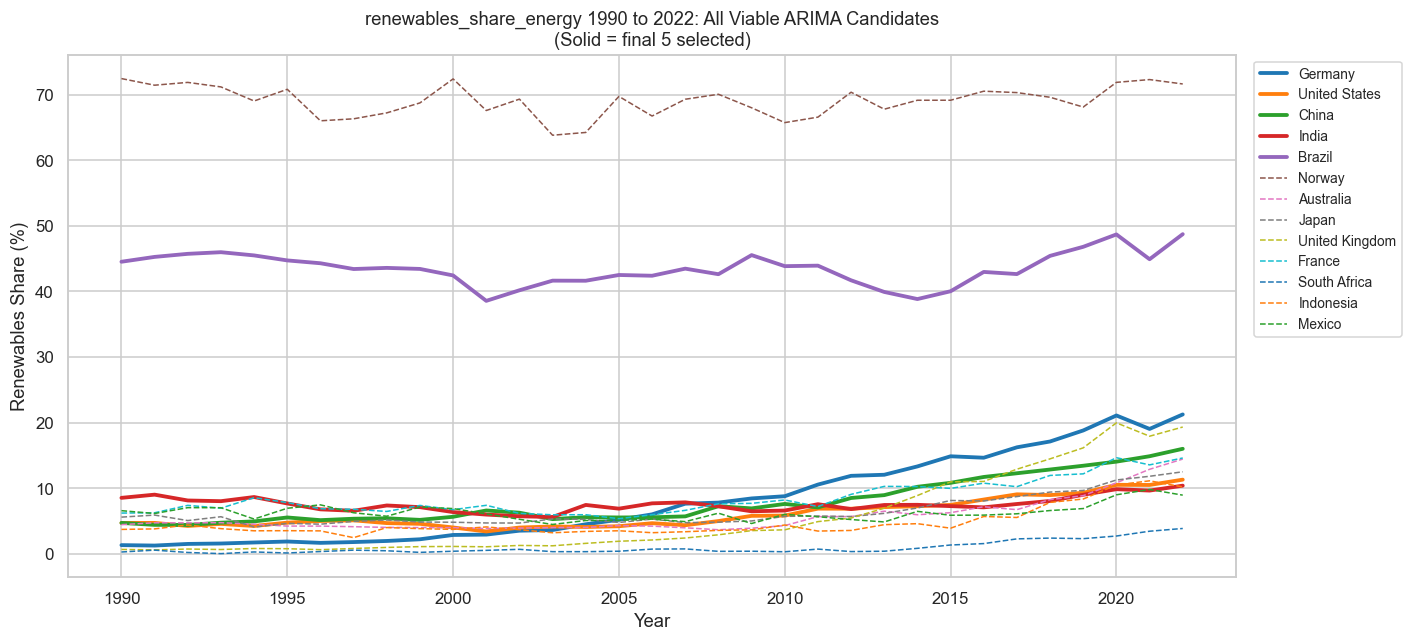

In [22]:
# Plot all viable candidates
good_candidates = [r['country'] for r in results if r['status'] == 'GOOD']

fig, ax = plt.subplots(figsize=(13, 6))
colors_map = plt.cm.tab10.colors
final_5 = ['Germany', 'United States', 'China', 'India', 'Brazil']

for i, c in enumerate(good_candidates):
    sub = df[(df['country'] == c) & (df['year'] >= 1990)].sort_values('year')
    vals = sub[['year', TARGET]].dropna()
    lw = 2.5 if c in final_5 else 1
    ls = '-'  if c in final_5 else '--'
    ax.plot(vals['year'], vals[TARGET], label=c,
            linewidth=lw, linestyle=ls, color=colors_map[i % 10])

ax.set_title('renewables_share_energy 1990 to 2022: All Viable ARIMA Candidates\n(Solid = final 5 selected)', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Renewables Share (%)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. Model 3 (ARIMA) - Final 5 Countries: Narrative Justification

Each country was chosen to represent a different trajectory archetype, maximising the narrative contrast in the ARIMA forecasts.

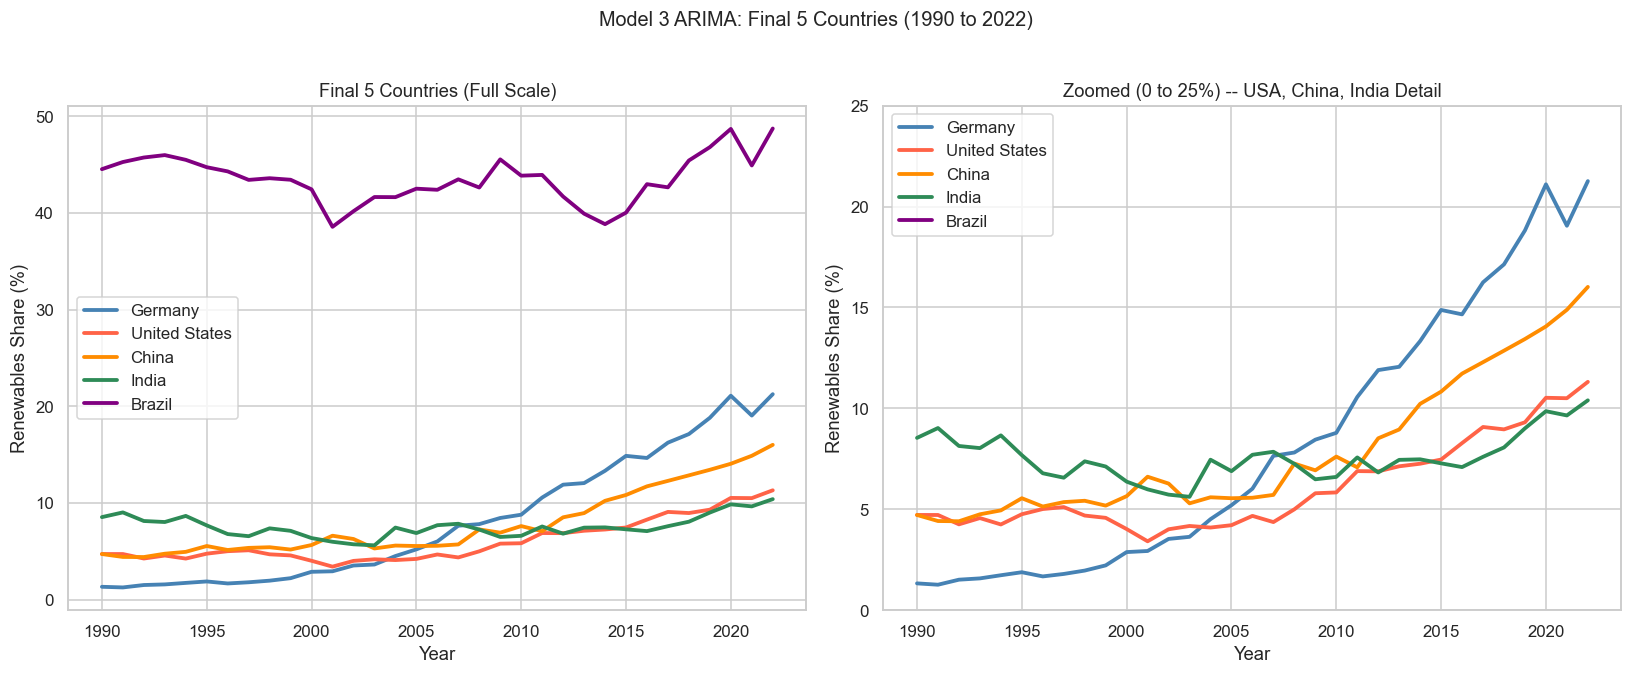

In [23]:
final_5  = ['Germany', 'United States', 'China', 'India', 'Brazil']
colors_5 = ['steelblue', 'tomato', 'darkorange', 'seagreen', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for c, col in zip(final_5, colors_5):
    sub = df[(df['country'] == c) & (df['year'] >= 1990)].sort_values('year')
    vals = sub[['year', TARGET]].dropna()
    axes[0].plot(vals['year'], vals[TARGET], label=c, linewidth=2.5, color=col)
    axes[1].plot(vals['year'], vals[TARGET], label=c, linewidth=2.5, color=col)

axes[0].set_title('Final 5 Countries (Full Scale)', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Renewables Share (%)')
axes[0].legend()

axes[1].set_ylim(0, 25)
axes[1].set_title('Zoomed (0 to 25%) -- USA, China, India Detail', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Renewables Share (%)')
axes[1].legend()

plt.suptitle('Model 3 ARIMA: Final 5 Countries (1990 to 2022)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Summary statistics table
roles = {
    'Germany': 'Policy-driven rapid transition (Energiewende)',
    'United States': 'Large economy, slow but accelerating',
    'China': 'Fastest absolute growth in renewables',
    'India': 'Low base, ambitious targets -- on track?',
    'Brazil': 'Hydro-dominated, high share but stagnant growth'
}

print('Final 5 Key Statistics')
print(f'{"Country":<16} {"1990":>8} {"2010":>8} {"2022":>8} {"Change (pp)":>14}  Narrative Role')
print('-' * 90)
for c in final_5:
    sub = df[(df['country'] == c) & (df['year'].isin([1990, 2010, 2022]))].set_index('year')[TARGET]
    v90 = sub.get(1990, float('nan'))
    v10 = sub.get(2010, float('nan'))
    v22 = sub.get(2022, float('nan'))
    chg = v22 - v90 if not (np.isnan(v90) or np.isnan(v22)) else float('nan')
    print(f'{c:<16} {v90:>8.1f} {v10:>8.1f} {v22:>8.1f} {chg:>14.1f}  {roles[c]}')

Final 5 Key Statistics
Country              1990     2010     2022    Change (pp)  Narrative Role
------------------------------------------------------------------------------------------
Germany               1.3      8.8     21.3           19.9  Policy-driven rapid transition (Energiewende)
United States         4.7      5.8     11.3            6.6  Large economy, slow but accelerating
China                 4.7      7.6     16.0           11.3  Fastest absolute growth in renewables
India                 8.5      6.6     10.4            1.9  Low base, ambitious targets -- on track?
Brazil               44.5     43.9     48.7            4.2  Hydro-dominated, high share but stagnant growth


---
## 8. Summary and Decisions

### Model 1 - MLP Neural Network

| Decision | Value |
|---|---|
| Cross-sectional year | 2018 (last year with energy_per_gdp data) |
| Final country count | 69 countries |
| Target range | 0.007% (Trinidad and Tobago) to 69.6% (Norway) |
| Tier coverage | 17 very low, 27 low, 18 medium, 7 high |
| Features | gas_share_elec, per_capita_electricity, fossil_elec_per_capita, gas_elec_per_capita, coal_share_energy, energy_per_gdp, energy_per_capita |
| Why new features | Original spec features (gdp, population, oil_share_energy) had mean r of 0.13. New features have mean r of 0.35, all non-circular |
| Key over-performers to watch | Norway, Brazil, Sweden, Colombia, Peru |
| Key under-performers to watch | Iraq, Trinidad and Tobago, Algeria, India, Russia |

### Model 3 - ARIMA Time Series

| Country | Rationale | Decision |
|---|---|---|
| Germany | 33 pts, +19.9pp - policy-driven story | Keep |
| United States | 33 pts, +6.6pp - large slow mover | Keep |
| China | 33 pts, +11.3pp - fastest absolute growth | Keep |
| India | 33 pts, +1.9pp - ambitious targets, slow pace | Keep |
| Saudi Arabia | 10 pts, all 0.0% - no trend, no usable series | Drop |
| Brazil | 33 pts, high base (44-49%) - interesting contrast with others | Replace Saudi Arabia |